# N-body gravity: simulate, measure, rediscover the law

Simulate two- and three-body gravity, measure it the way a tracking system
would (accelerations by finite differences), and ask two equation-discovery
methods to find Newton's law from the measurements alone.

The concise counterpart of `03_nbody_full_pipeline.ipynb`, kept as it was.
Simulation, measurement and discovery are `src/nbody.py`; figures
`src/plots.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
from core import viz_style as vs
import plots

vs.use_style()
from nbody import (two_body, three_body, simulate, measure, planet_radial,
                   discover_force_law, discover_dynamics)

## Simulate

A planet on an e = 0.3 orbit, and three equal masses in the figure-8 choreography.

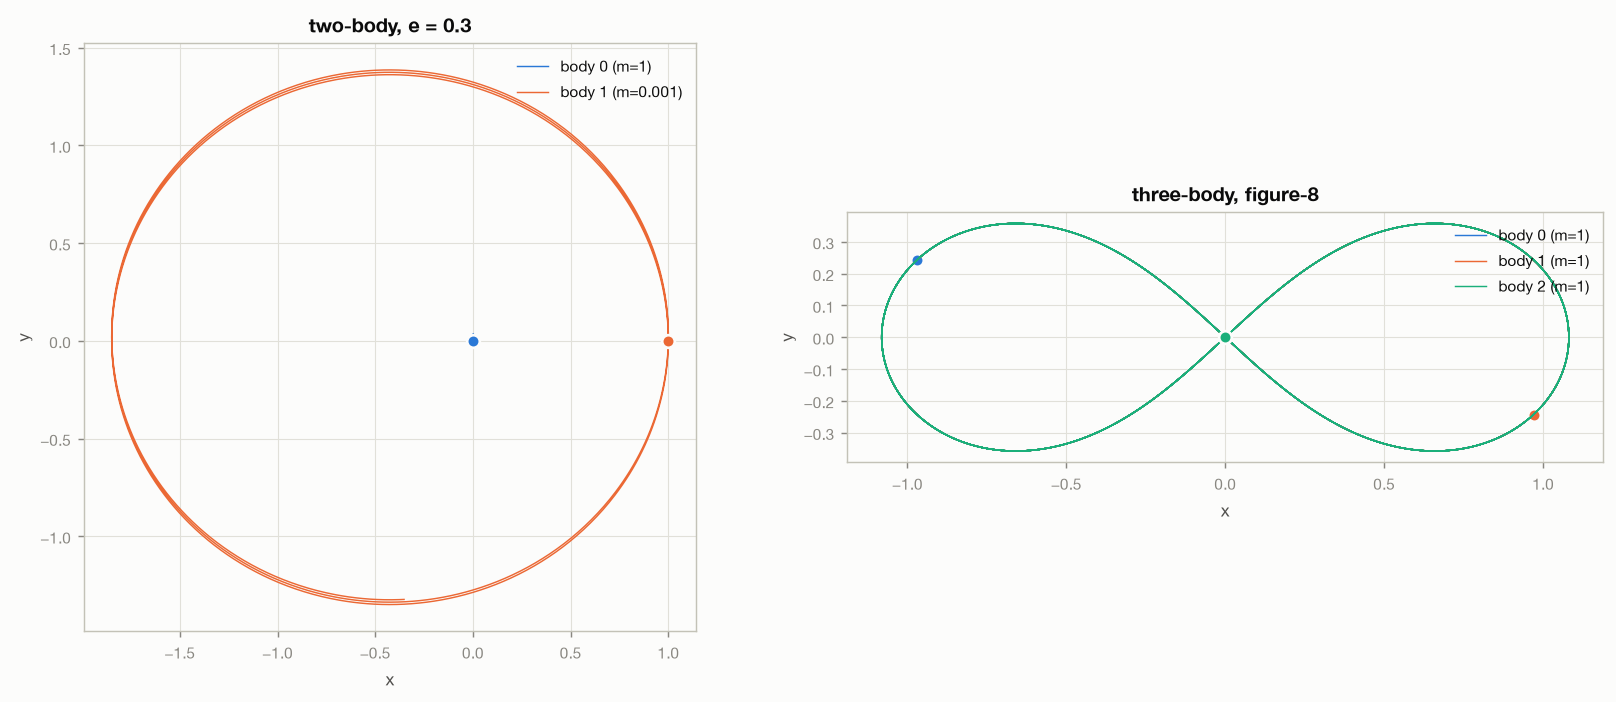

In [2]:
two = simulate(*two_body(eccentricity=0.3), t_end=30, n_samples=2000, label="two-body, e = 0.3")
three = simulate(*three_body("figure8"), t_end=40, n_samples=4000, label="three-body, figure-8")
plots.orbits(two, three);

## Measure

Energy and angular momentum drift by ~1e-9 over the run, so the integrator
is not what limits anything below. (The original notebook set only a
relative tolerance; solve_ivp's default absolute tolerance of 1e-6 then
capped the drift near 1e-5.)

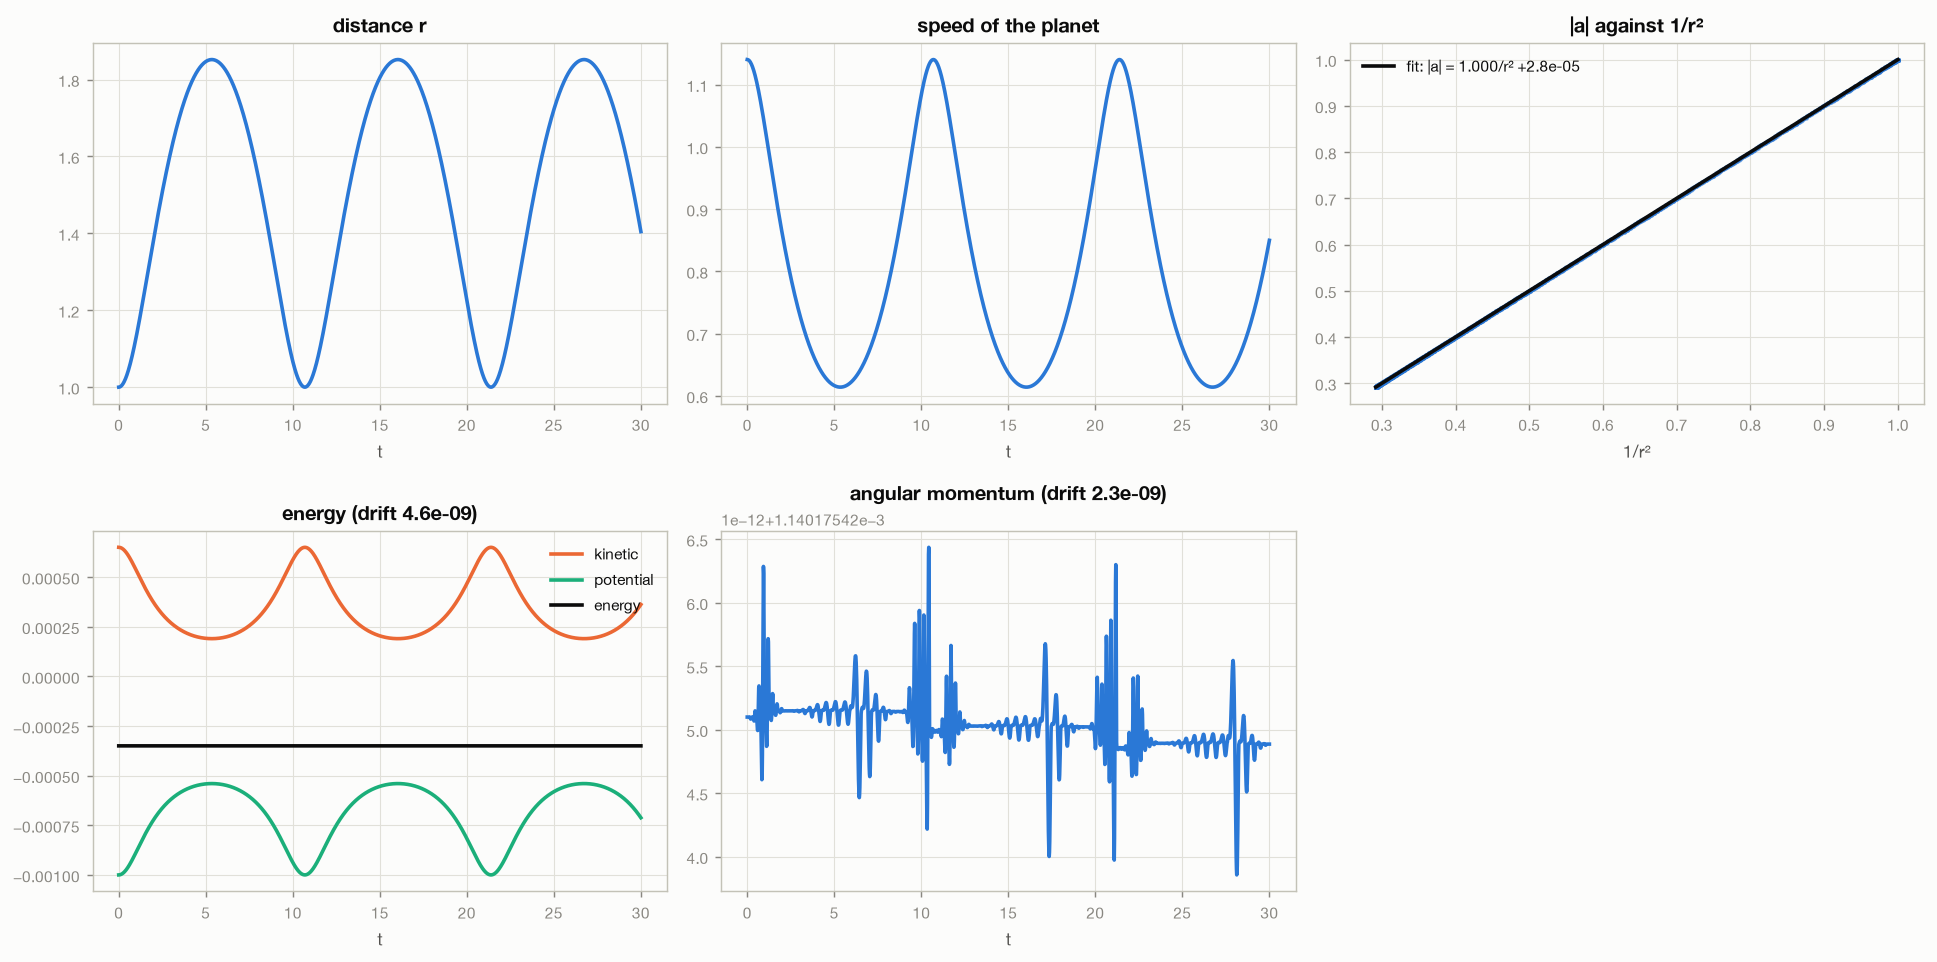

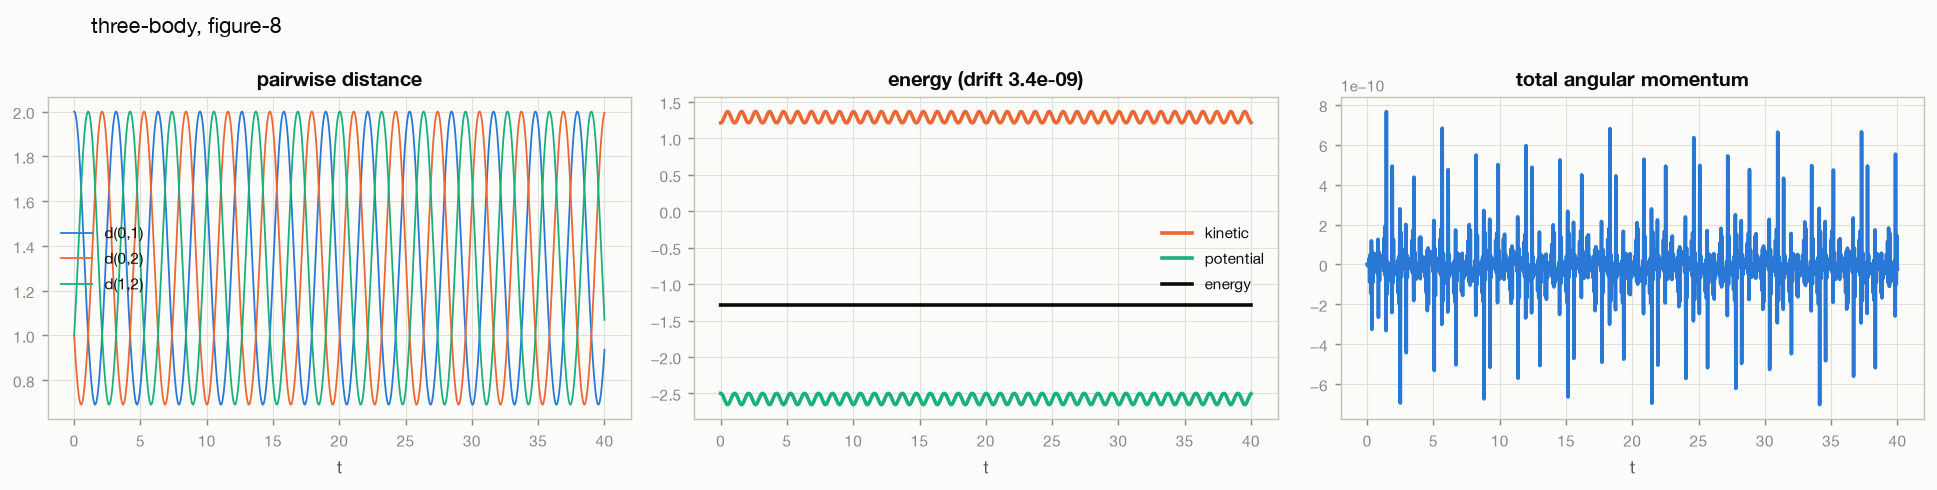

In [3]:
m2, m3 = measure(two), measure(three)
r, a = planet_radial(two)
plots.two_body_measurements(two, m2, r, a);
plots.conservation(m3, title="three-body, figure-8");

## Discover the force law: PySR on (r, |a|)

Symbolic regression over `+ - * /`, `square`, `inv`, `sqrt`. The relative
acceleration of the planet is G(M + m)/r² = 1.001/r².

In [4]:
pysr_model = discover_force_law(r, a, niterations=30)
pysr_model.equations_[["complexity", "loss", "equation"]].head(4)

,complexity,loss,equation
0,1,5.084523e-02,0.49792096
1,2,4.266239e-02,inv(r)
2,3,4.240165e-09,inv(square(r))
3,5,3.770569e-09,inv(square(r) + 5.3009164e-5)


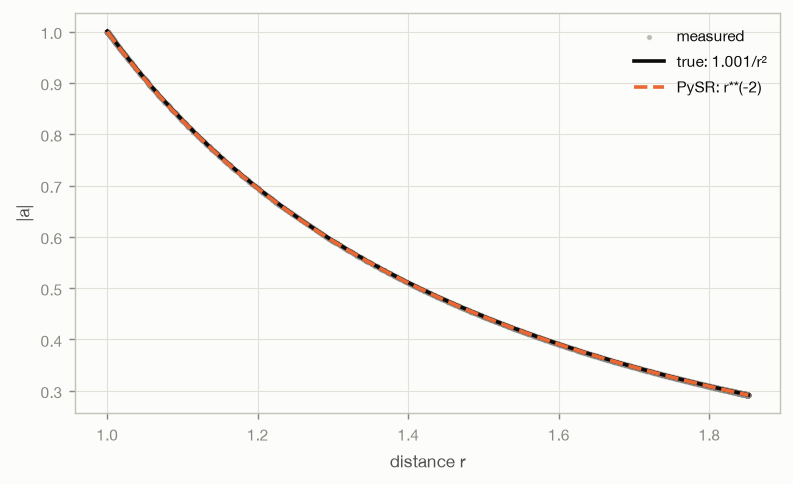

In [5]:
plots.force_law(r, a, pysr_model, gm=1.001);

## Discover the equations of motion: SINDy on (x, y, vx, vy)

The candidate library decides what SINDy can find. Polynomials up to degree 2
- the original notebook's choice - cannot express gravity's 1/r³, so the fit
returns a tangle of terms and the rollout leaves the orbit. Adding x/r³ and
y/r³ to the library, SINDy returns Newton's law with the right constant.

In [6]:
fits = {f"{lib} library": discover_dynamics(two, library=lib) for lib in ("polynomial", "gravity")}
for label, (model, _, _) in fits.items():
    print(label); model.print(precision=4)

polynomial library
(x)' = -385.6389 y + -625.3477 vx + -144.0599 y vy
(y)' = -3919.1764 1 + -1902.5801 x +  768.4644 vy + -710.7310 x vy +  4428.5160 vx^2 +  4428.5156 vy^2
(vx)' = -0.3094 1 + -0.3748 x +  0.4249 vx^2 + -0.2414 vy^2
(vy)' =  1040.3256 y +  916.0781 vx + -0.0835 x y + -1817.7288 x vx + -1606.7243 y vy +  0.8832 vx vy
gravity library
(x)' =  0.0002 y +  1.0007 vx +  0.0006 y/r^3
(y)' =  0.9999 vy
(vx)' = -1.0009 x/r^3
(vy)' = -1.0009 y/r^3


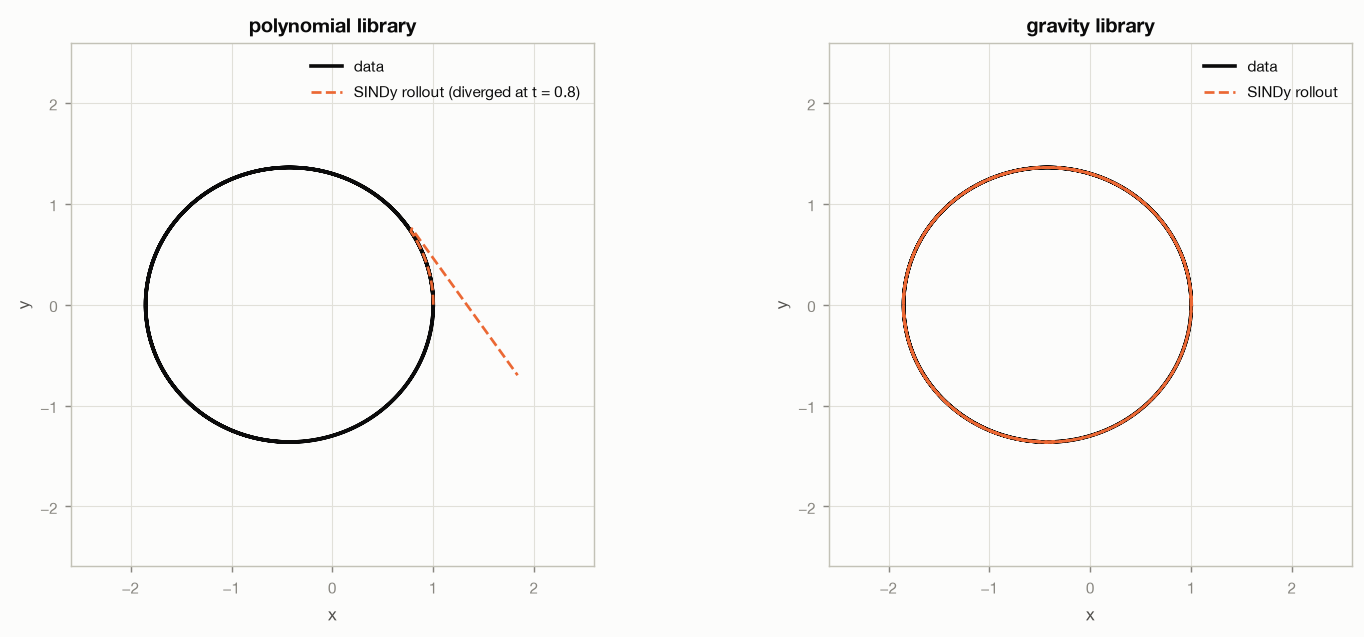

In [7]:
plots.sindy_rollouts(fits);

The figure-8 is one of the rare periodic three-body solutions: all three
bodies return to their start after one period (T ≈ 6.33). Most initial
conditions are chaotic (try `three_body("triangle")`). The original
notebook's figure-8 velocities were slightly off (vy 0.4662 instead of
0.4324), enough to turn the choreography into chaotic close encounters.
Chaos makes long rollouts diverge, but the law itself is still pairwise
1/r², and a library holding those terms would recover it.